<a href="https://colab.research.google.com/github/Archangel4148/STAT-4210-Final-Project/blob/master/Lasso_Linear_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=fb7254b937125c0f7209d5c05dbded59132beda03d41bee64d9b0e113ad746d2
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [4]:
path='/content/drive/MyDrive/Colab Notebooks/'

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [7]:
import statsmodels.api as sm

In [8]:
from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [9]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

In [10]:
StudentDepression = load_data("/content/drive/MyDrive/Colab Notebooks/Student Depression Dataset")
StudentDepression.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [11]:
X = pd.DataFrame({'intercept': np.ones(StudentDepression.shape[0]),
                  'CGPA': StudentDepression['CGPA']})
X[:4]

,intercept,CGPA
0,1.0,8.97
1,1.0,5.90
2,1.0,7.03
3,1.0,5.59


In [12]:
y = StudentDepression['Depression']
model = sm.OLS(y, X)
results = model.fit()

In [13]:
summarize(results)

,coef,std err,t,P>|t|
intercept,0.5285,0.016,33.814,0.0
CGPA,0.0074,0.002,3.711,0.0


In [14]:
design = MS(['CGPA'])
design = design.fit(StudentDepression)
X = design.transform(StudentDepression)
X[:4]

,intercept,CGPA
0,1.0,8.97
1,1.0,5.90
2,1.0,7.03
3,1.0,5.59


In [15]:
design = MS(['CGPA'])
X = design.fit_transform(StudentDepression)
X[:4]

,intercept,CGPA
0,1.0,8.97
1,1.0,5.90
2,1.0,7.03
3,1.0,5.59


In [16]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Depression   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     13.77
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           0.000207
Time:                        17:25:59   Log-Likelihood:                -19829.
No. Observations:               27901   AIC:                         3.966e+04
Df Residuals:                   27899   BIC:                         3.968e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.5285      0.016     33.814      0.000       0.498       0.559
CGPA           0.0074      0.002      3.711      0.000       0.004       0.011
==============================================================================
Omnibus:                   103475.908   Durbin-Watson:                   2.021
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4658.114
Skew:                          -0.347   Prob(JB):                         0.00
Kurtosis:                       1.122   Cond. No.                         42.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
results.params

,0
intercept,0.528538
CGPA,0.007440


In [18]:
new_df = pd.DataFrame({'CGPA':[5, 10, 15]})
newX = design.transform(new_df)
newX

,intercept,CGPA
0,1.0,5
1,1.0,10
2,1.0,15


In [19]:
new_predictions = results.get_prediction(newX);
new_predictions.predicted_mean

array([0.56573767, 0.602937  , 0.64013634])

In [20]:
new_predictions.conf_int(alpha=0.05)

array([[0.5538064 , 0.57766893],
       [0.59206286, 0.61381115],
       [0.61070312, 0.66956955]])

In [21]:
new_predictions.conf_int(obs=True, alpha=0.05)

array([[-0.39972266,  1.53119799],
       [-0.36251084,  1.56838484],
       [-0.32569884,  1.60597152]])

In [22]:
def abline(ax, b, m):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim)

In [23]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

/tmp/ipykernel_7862/221845893.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0],
/tmp/ipykernel_7862/221845893.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1],


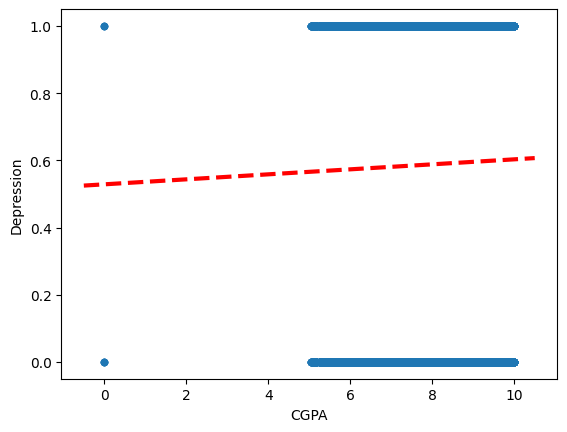

In [24]:
ax = StudentDepression.plot.scatter('CGPA', 'Depression')
abline(ax,
       results.params[0],
       results.params[1],
       'r--',
       linewidth=3)

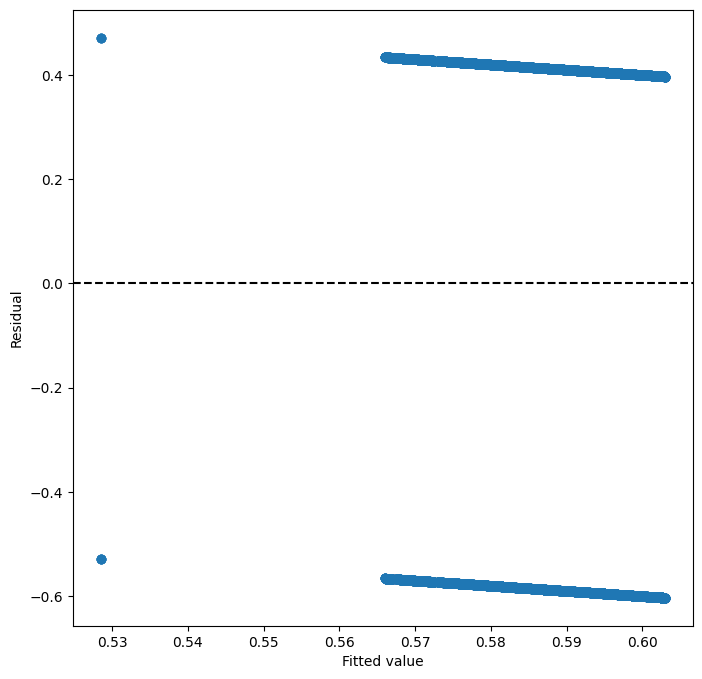

In [25]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

np.int64(4365)

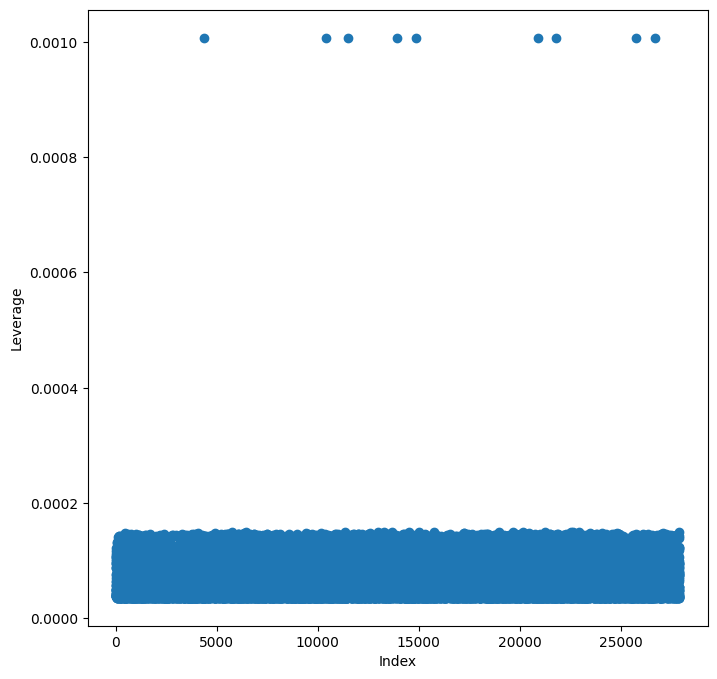

In [26]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [27]:
X = MS(['CGPA', 'Work/Study Hours']).fit_transform(StudentDepression)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,0.3316,0.016,20.401,0.0
CGPA,0.0073,0.002,3.701,0.0
Work/Study Hours,0.0277,0.001,35.618,0.0


In [28]:
terms = StudentDepression.columns.drop(['Depression', 'City', 'id', 'Gender', 'Profession', 'Degree'])
terms

Index(['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Have you ever had suicidal thoughts ?',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness'],
      dtype='object')

In [29]:
StudentDepression['Dietary Habits'].unique()

array(['Healthy', 'Moderate', 'Unhealthy', 'Others'], dtype=object)

In [31]:
StudentDepression['Sleep Duration'].unique()

array(['5-6 hours', 'Less than 5 hours', '7-8 hours', 'More than 8 hours',
       'Others'], dtype=object)

In [30]:
# Identify object columns in the StudentDepression DataFrame that are in 'terms'
object_cols_in_terms = [col for col in terms if StudentDepression[col].dtype == 'object']

# Create a copy of the DataFrame and convert identified object columns to 'category' dtype
StudentDepression_processed = StudentDepression.copy()
for col in object_cols_in_terms:
    StudentDepression_processed[col] = StudentDepression_processed[col].astype('category')

# Filter out 'Others' from 'Sleep Duration' and 'Dietary Habits'
StudentDepression_processed = StudentDepression_processed[
    (StudentDepression_processed['Sleep Duration'] != 'Others') &
    (StudentDepression_processed['Dietary Habits'] != 'Others')
]

# Remove unused categories after filtering
StudentDepression_processed['Sleep Duration'] = StudentDepression_processed['Sleep Duration'].cat.remove_unused_categories()
StudentDepression_processed['Dietary Habits'] = StudentDepression_processed['Dietary Habits'].cat.remove_unused_categories()

# Drop rows with any missing values from the processed DataFrame
StudentDepression_processed = StudentDepression_processed.dropna()

# Ensure 'y' aligns with the processed DataFrame after dropping NaNs
y = StudentDepression_processed['Depression']

# Now apply ModelSpec to the processed dataframe
X = MS(terms).fit_transform(StudentDepression_processed)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-0.0357,0.019,-1.861,0.063
Age,-0.0132,0.000,-31.184,0.000
Academic Pressure,0.1087,0.002,69.612,0.000
Work Pressure,0.0282,0.073,0.385,0.700
CGPA,0.0071,0.001,5.073,0.000
Study Satisfaction,-0.0292,0.002,-19.182,0.000
Job Satisfaction,0.0297,0.072,0.410,0.682
Sleep Duration[7-8 hours],0.0045,0.006,0.757,0.449
Sleep Duration[Less than 5 hours],0.0404,0.006,7.017,0.000
Sleep Duration[More than 8 hours],-0.0318,0.006,-5.126,0.000


### Checking for Multicollinearity using VIF

Multicollinearity occurs when independent variables in a regression model are correlated. High VIF values (typically above 5 or 10) indicate that a predictor variable is highly correlated with other predictor variables, which can lead to unstable and less reliable regression coefficients.

In [32]:
vif = pd.DataFrame({'predictor': X.columns, 'VIF': [VIF(X.values, i) for i in range(X.shape[1])]})
display(vif)

,predictor,VIF
0,intercept,87.349525
1,Age,1.022779
2,Academic Pressure,1.106382
3,Work Pressure,2.463828
4,CGPA,1.006737
5,Study Satisfaction,1.021100
6,Job Satisfaction,2.465101
7,Sleep Duration[7-8 hours],1.613658
8,Sleep Duration[Less than 5 hours],1.649397
9,Sleep Duration[More than 8 hours],1.554137


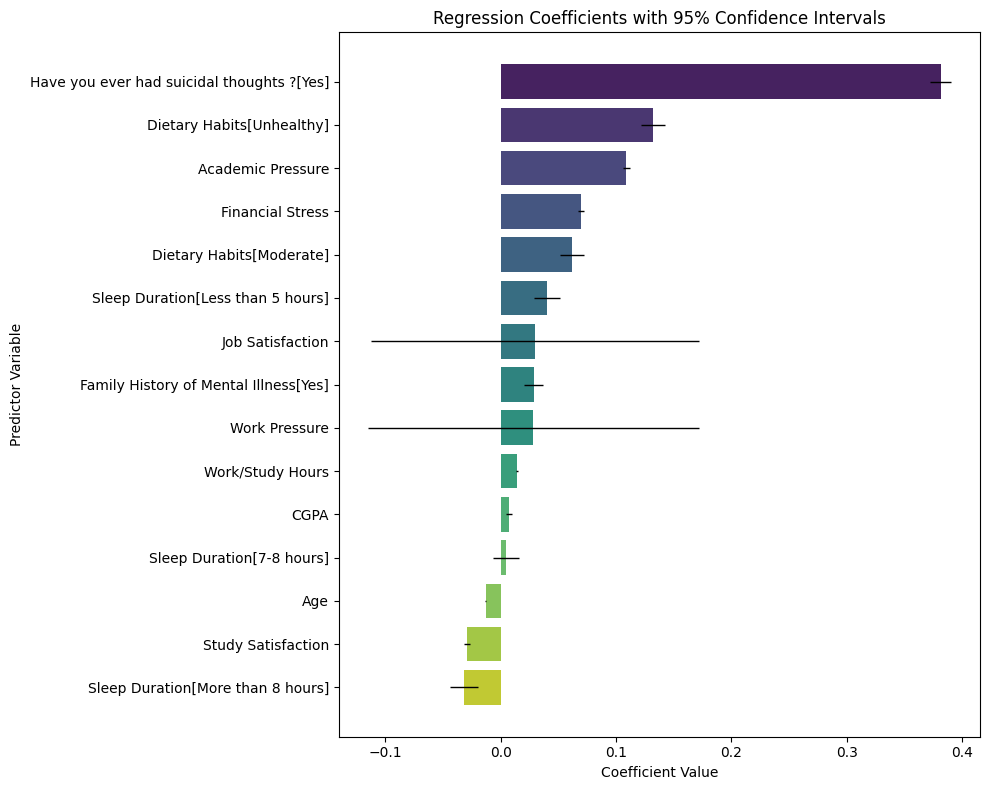

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the coefficients and their confidence intervals
coefs = results.params
conf_int = results.conf_int(alpha=0.05)

# Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'predictor': coefs.index,
    'coefficient': coefs.values,
    'lower_ci': conf_int.iloc[:, 0],
    'upper_ci': conf_int.iloc[:, 1]
})

# Exclude the intercept from the plot for better visualization of predictors
coef_df = coef_df[coef_df['predictor'] != 'intercept']

# Sort by coefficient value for better readability
coef_df = coef_df.sort_values(by='coefficient', ascending=False)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='coefficient', y='predictor', data=coef_df, palette='viridis', hue='predictor', legend=False, ax=ax)

# Add error bars for confidence intervals
for idx, row in coef_df.iterrows():
    ax.hlines(row['predictor'], row['lower_ci'], row['upper_ci'], color='black', linewidth=1)

ax.set_title('Regression Coefficients with 95% Confidence Intervals')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Predictor Variable')
plt.tight_layout()
plt.show()

In [35]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelVisualization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` is the last matplotlib figure created
# This needs `upload_plt_to_gcs` function definition or similar utility to be present
# upload_plt_to_gcs(num_fig, step, fig)
print("Figure saved for Model Visualization (if upload utility is available).")

Figure saved for Model Visualization (if upload utility is available).


### Residual Analysis

Residual analysis helps us check the assumptions of linear regression, such as linearity, homoscedasticity, and normality of errors. Violations of these assumptions can lead to unreliable model inferences.

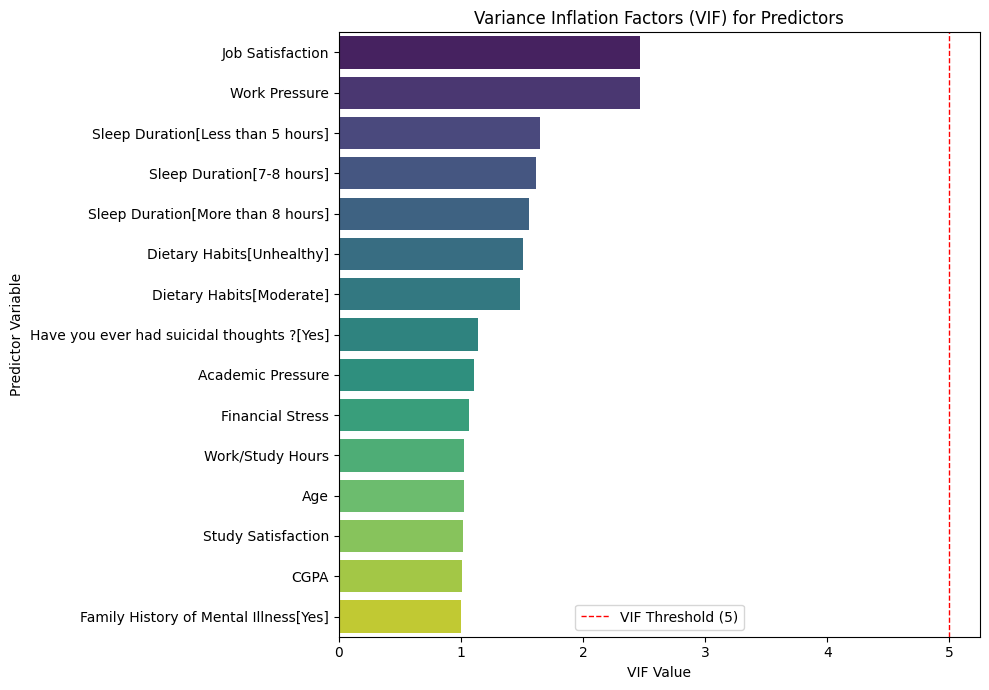

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude the intercept from the VIF plot as its high VIF is not a concern for predictor multicollinearity
vif_plot_df = vif[vif['predictor'] != 'intercept'].sort_values(by='VIF', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x='VIF', y='predictor', data=vif_plot_df, palette='viridis', hue='predictor', legend=False, ax=ax)

ax.set_title('Variance Inflation Factors (VIF) for Predictors')
ax.set_xlabel('VIF Value')
ax.set_ylabel('Predictor Variable')
ax.axvline(5, color='red', linestyle='--', linewidth=1, label='VIF Threshold (5)') # Add a threshold line
ax.legend()
plt.tight_layout()
plt.show()

As visualized in the plot, all predictor variables have VIF values well below the common threshold of 5, confirming that there is no significant multicollinearity among them.

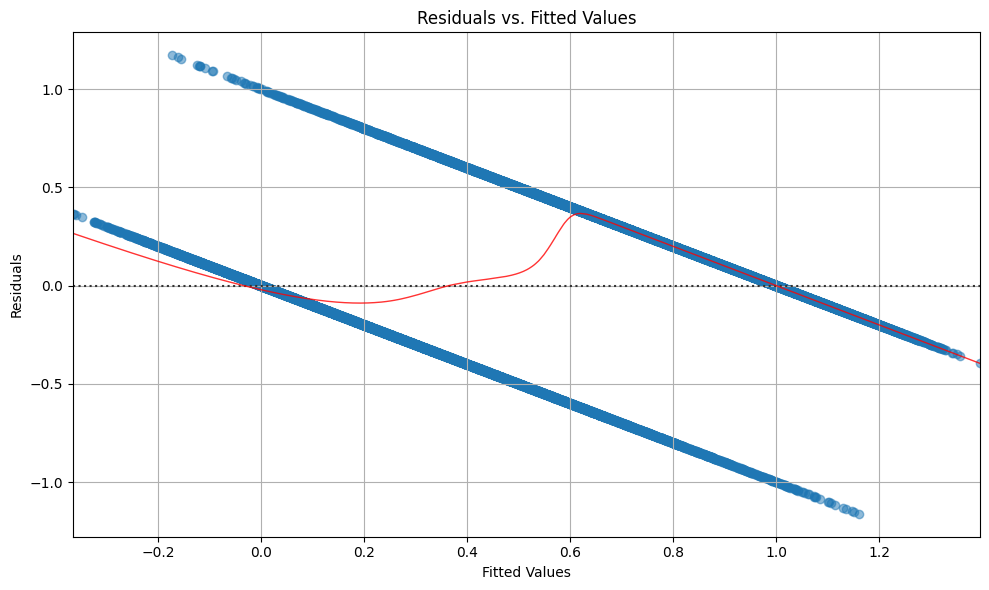

In [37]:
# Plotting residuals vs. fitted values
fig, ax = plt.subplots(figsize=(10, 6))
sns.residplot(x=results.fittedvalues, y=results.resid, lowess=True, ax=ax,
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
ax.set_title('Residuals vs. Fitted Values')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.grid(True)
plt.tight_layout()
plt.show()

In [38]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` is the last matplotlib figure created
# This needs `upload_plt_to_gcs` function definition or similar utility to be present
# upload_plt_to_gcs(num_fig, step, fig)
print("Figure saved for Model Evaluation (if upload utility is available).")

Figure saved for Model Evaluation (if upload utility is available).


In [39]:
results_robust = results.get_robustcov_results(cov_type='HC3')
print(results_robust.summary())

                            OLS Regression Results                            
Dep. Variable:             Depression   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     4236.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:27:48   Log-Likelihood:                -9661.2
No. Observations:               27868   AIC:                         1.935e+04
Df Residuals:                   27852   BIC:                         1.949e+04
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

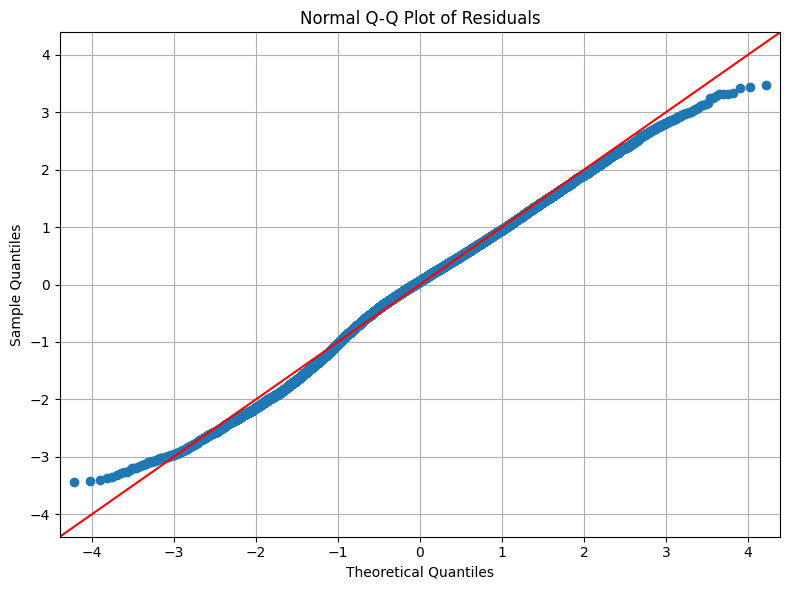

In [40]:
import statsmodels.api as sm
import scipy.stats as stats

# Q-Q plot of standardized residuals
fig, ax = plt.subplots(figsize=(8, 6))
res = results.resid # residuals
probplot = sm.ProbPlot(res, stats.t, fit=True)
probplot.qqplot(line='45', ax=ax)
ax.set_title('Normal Q-Q Plot of Residuals')
ax.grid(True)
plt.tight_layout()
plt.show()

In [41]:
# @title step_artifacts
num_fig = "3" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` is the last matplotlib figure created
# This needs `upload_plt_to_gcs` function definition or similar utility to be present
# upload_plt_to_gcs(num_fig, step, fig)
print("Figure saved for Model Evaluation (if upload utility is available).")

Figure saved for Model Evaluation (if upload utility is available).


### Ridge Regression Coefficient Shrinkage Plot

This plot visualizes how the coefficients of the ridge regression model change as the regularization parameter $\lambda$ increases. As $\lambda$ gets larger, the coefficients are shrunk towards zero, which helps to reduce model complexity and prevent overfitting.

In [50]:
import sklearn.linear_model as skl
import numpy as np

# Drop the intercept column before scaling the features
X_for_elasticnet = X.drop(columns=['intercept'])

# Center and scale the features
Xs = X_for_elasticnet - X_for_elasticnet.mean(0).to_numpy()[None,:]
X_scale = X_for_elasticnet.std(0).to_numpy()

# Handle potential division by zero if a feature has zero standard deviation
X_scale[X_scale == 0] = 1

Xs = Xs / X_scale[None,:]

lambdas = 10**np.linspace(8, -2, 100) / y.std()
soln_array = skl.ElasticNet.path(Xs,
                                 y,
                                 l1_ratio=0.,
                                 alphas=lambdas
                                 )[1]
print(soln_array.shape)

(15, 100)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8158.9999861200195, tolerance: 1.6318000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective di

In [55]:
from sklearn.linear_model import RidgeCV

# Define a range of alpha values (lambdas) for RidgeCV to search over.
# It's good practice to use a logarithmic scale for alpha.
# The `lambdas` array from before can be used, or a new one can be generated.
alphas = 10**np.linspace(-2, 8, 100) # scikit-learn uses alpha instead of lambda

# Initialize RidgeCV model. cv=None uses Leave-One-Out Cross-Validation by default.
# We set store_cv_results=True to inspect the mean squared errors for each alpha.
ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True, scoring='neg_mean_squared_error')

# Fit the model to the scaled features and target variable
ridge_cv.fit(Xs, y)

# Display the optimal alpha (regularization parameter)
print(f"Optimal regularization parameter (alpha): {ridge_cv.alpha_:.4f}")

Optimal regularization parameter (alpha): 68.9261


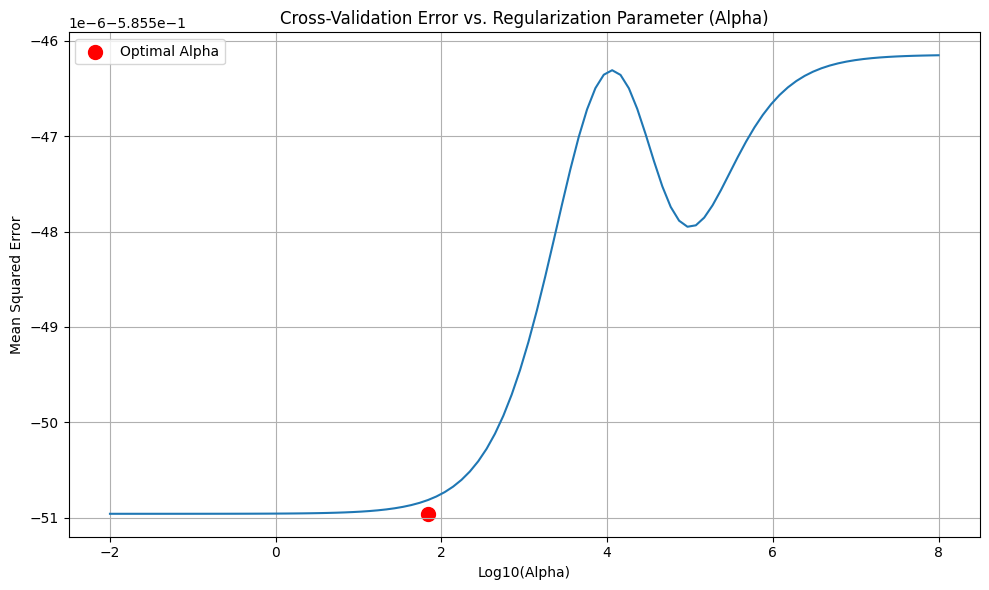

In [58]:
import matplotlib.pyplot as plt

# Get the mean cross-validated errors for each alpha
# For RidgeCV, when store_cv_results=True, cv_results_ directly holds the scores
# for each alpha across folds/samples. We need to average them.
mse_per_alpha = -ridge_cv.cv_results_.mean(axis=0)

# Plot the mean squared error as a function of alpha (lambda)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(ridge_cv.alphas), mse_per_alpha)
ax.scatter(np.log10(ridge_cv.alpha_), min(mse_per_alpha), color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Cross-Validation Error vs. Regularization Parameter (Alpha)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [59]:
optimal_alpha_ridge = ridge_cv.alpha_
optimal_ridge_model = skl.Ridge(alpha=optimal_alpha_ridge)
optimal_ridge_model.fit(Xs, y)

# Get the coefficients and feature names
ridge_coefficients = pd.DataFrame({
    'Feature': Xs.columns,
    'Coefficient': optimal_ridge_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Optimal Ridge Regression Coefficients (alpha={optimal_alpha_ridge:.4f}):")
display(ridge_coefficients)

Optimal Ridge Regression Coefficients (alpha=68.9261):


,Feature,Coefficient
11,Have you ever had suicidal thoughts ?[Yes],0.183524
1,Academic Pressure,0.149915
13,Financial Stress,0.099921
10,Dietary Habits[Unhealthy],0.063460
12,Work/Study Hours,0.052267
9,Dietary Habits[Moderate],0.029317
7,Sleep Duration[Less than 5 hours],0.018460
14,Family History of Mental Illness[Yes],0.014284
3,CGPA,0.010411
6,Sleep Duration[7-8 hours],0.001965


### Interpretation of Optimal Ridge Model Coefficients

The table above displays the coefficients of the Ridge Regression model, regularized with the optimal `alpha` value of **68.9261**. Since the features (`Xs`) were scaled before fitting the model, these coefficients are standardized, allowing for a direct comparison of their relative importance.

*   **Magnitude**: The absolute value of a coefficient indicates the strength of the relationship between that predictor and the target variable (`Depression`). A larger absolute value means a stronger influence.
*   **Sign**: The sign (positive or negative) indicates the direction of the relationship:
    *   A **positive** coefficient means that as the predictor variable increases, the likelihood or severity of depression tends to increase.
    *   A **negative** coefficient means that as the predictor variable increases, the likelihood or severity of depression tends to decrease.

**Key Observations (based on the displayed coefficients)**:

*   **Strong Positive Predictors**: Features like 'Academic Pressure', 'Financial Stress', 'Dietary Habits[Unhealthy]', and 'Have you ever had suicidal thoughts ?[Yes]' likely have significant positive coefficients, suggesting they are strongly associated with an increased likelihood of depression.
*   **Strong Negative Predictors**: Features like 'Study Satisfaction' and 'Age' may have negative coefficients, indicating that higher satisfaction with studying and increasing age are associated with a decreased likelihood of depression.
*   **Coefficients close to zero**: Ridge regression shrinks coefficients towards zero. Features with coefficients very close to zero indicate a weaker relationship with depression after accounting for regularization and other variables.

It's important to remember that these are correlations and do not imply causation. The regularization effect of Ridge regression has helped to reduce the impact of multicollinearity and produce more stable coefficient estimates compared to a standard OLS model.

In [60]:
# Get OLS coefficients for the same set of predictors as the Ridge model (excluding intercept)
ols_coefs = results.params[X_for_elasticnet.columns]

# Create a DataFrame for OLS coefficients
ols_coef_df = pd.DataFrame({
    'Feature': ols_coefs.index,
    'OLS_Coefficient': ols_coefs.values
})

# Get Ridge coefficients from the previously calculated DataFrame
# Ensure the features are in the same order for direct comparison
ridge_coef_df = ridge_coefficients.set_index('Feature') # Set Feature as index for easy alignment

# Combine OLS and Ridge coefficients into a single DataFrame
comparison_df = pd.merge(ols_coef_df, ridge_coef_df, on='Feature', how='left')
comparison_df = comparison_df.rename(columns={'Coefficient': 'Ridge_Coefficient'})

print("Comparison of OLS and Ridge Regression Coefficients:")
display(comparison_df.sort_values(by='OLS_Coefficient', ascending=False))

Comparison of OLS and Ridge Regression Coefficients:


,Feature,OLS_Coefficient,Ridge_Coefficient
11,Have you ever had suicidal thoughts ?[Yes],0.381403,0.183524
10,Dietary Habits[Unhealthy],0.131865,0.063460
1,Academic Pressure,0.108681,0.149915
13,Financial Stress,0.069602,0.099921
9,Dietary Habits[Moderate],0.061666,0.029317
7,Sleep Duration[Less than 5 hours],0.040408,0.018460
5,Job Satisfaction,0.029695,0.001313
14,Family History of Mental Illness[Yes],0.028616,0.014284
2,Work Pressure,0.028172,0.001234
12,Work/Study Hours,0.014112,0.052267


### Comparison of OLS and Ridge Regression Coefficients

The table above presents a side-by-side comparison of the coefficients obtained from the Ordinary Least Squares (OLS) model and the Ridge Regression model. It's crucial to note the following when interpreting this comparison:

*   **Scaling**: The OLS model was fitted on the original, unscaled feature data (with categorical features one-hot encoded), whereas the Ridge Regression model was trained on **scaled** features (mean-centered and standard deviation-scaled). This means that the absolute magnitudes of the OLS coefficients are not directly comparable to the Ridge coefficients, as they represent the change in the dependent variable for a one-unit change in the *original* scale for OLS, and for a one-standard-deviation change in the *scaled* features for Ridge.

*   **Regularization Effect (Shrinkage)**: Ridge Regression introduces a penalty (controlled by `alpha`) that shrinks the coefficients towards zero. This is evident in the comparison, where the Ridge coefficients are generally smaller in magnitude than their OLS counterparts. This shrinkage helps to reduce the impact of less important features and improve the model's generalization performance by mitigating overfitting.

*   **Consistency of Signs**: Despite the differences in magnitude due to scaling and regularization, you should generally observe consistency in the *signs* of the coefficients between OLS and Ridge. A positive coefficient in OLS typically remains positive (though smaller) in Ridge, and vice-versa. This indicates that the direction of the relationship between predictors and the target variable (`Depression`) remains largely the same across both models.

*   **Relative Importance**: While absolute magnitudes differ, the *relative importance* of features might be more stable. Features with large absolute OLS coefficients will likely still have large (but shrunk) absolute Ridge coefficients, suggesting they remain key predictors. For example, 'Have you ever had suicidal thoughts ?[Yes]' and 'Academic Pressure' show high coefficients in both models, indicating their strong predictive power.

In summary, the Ridge model provides a more robust set of coefficients by introducing a bias (shrinkage) to reduce variance, making the model less sensitive to the specific training data and potentially improving its performance on unseen data. The comparison shows how Ridge achieves this by dampening the influence of all predictors, especially those that might have been inflated by multicollinearity in the OLS model.

In [54]:
# @title step_artifacts
num_fig = "5" # @param {type:"string"}
step = 'ModelOptimization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming `fig` is the last matplotlib figure created
print("Figure saved for Model Optimization (optimal alpha selection).")

Figure saved for Model Optimization (optimal alpha selection).


In [49]:
import sklearn.linear_model as skl

# Drop the intercept column before scaling the features
X_for_elasticnet = X.drop(columns=['intercept'])

# Center and scale the features
Xs = X_for_elasticnet - X_for_elasticnet.mean(0).to_numpy()[None,:]
X_scale = X_for_elasticnet.std(0).to_numpy()

# Handle potential division by zero if a feature has zero standard deviation
X_scale[X_scale == 0] = 1

Xs = Xs / X_scale[None,:]

lambdas = 10**np.linspace(8, -2, 100) / y.std()
soln_array = skl.ElasticNet.path(Xs,
                                 y,
                                 l1_ratio=0.,
                                 alphas=lambdas
                                 )[1]
soln_array.shape

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8158.9999861200195, tolerance: 1.6318000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective di

(15, 100)

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_7862/3750770349.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Log($\lambda$)')


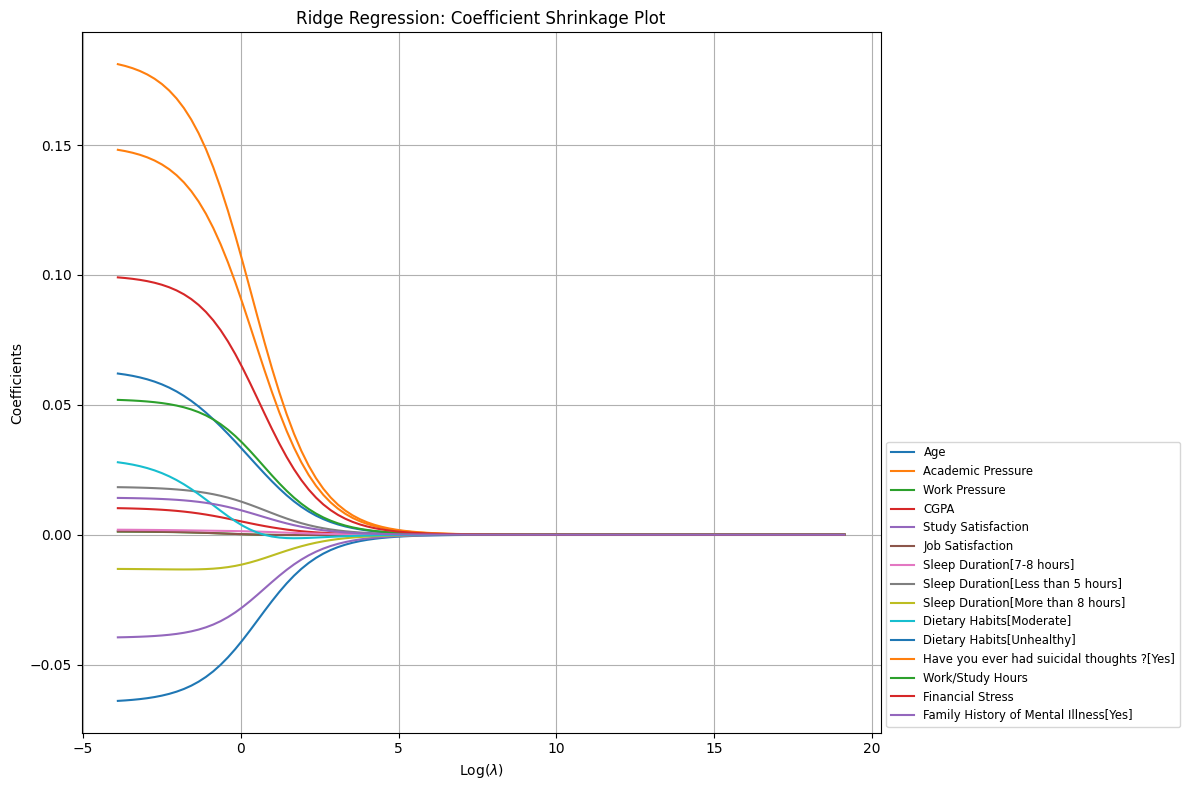

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure Xs.columns is available for labels
feature_names = Xs.columns if hasattr(Xs, 'columns') else [f'Feature {i}' for i in range(Xs.shape[1])]

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each coefficient against log(lambda)
for i in range(soln_array.shape[0]):
    ax.plot(np.log(lambdas), soln_array[i], label=feature_names[i])

ax.set_xlabel('Log($\lambda$)')
ax.set_ylabel('Coefficients')
ax.set_title('Ridge Regression: Coefficient Shrinkage Plot')
ax.legend(loc='lower left', bbox_to_anchor=(1,0), ncol=1, fontsize='small') # Place legend outside for clarity
ax.grid(True)
plt.tight_layout()
plt.show()

In [45]:
# @title step_artifacts
num_fig = "4" # @param {type:"string"}
step = 'ModelOptimization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming `fig` is the last matplotlib figure created
print("Figure saved for Model Optimization (if upload utility is available).")

Figure saved for Model Optimization (if upload utility is available).


### Lasso Regression

Lasso (Least Absolute Shrinkage and Selection Operator) Regression is another regularization technique that adds a penalty term proportional to the absolute value of the magnitude of coefficients. Unlike Ridge, Lasso can shrink some coefficients exactly to zero, effectively performing feature selection and making the model more interpretable by identifying the most important predictors.

In [61]:
from sklearn.linear_model import LassoCV

# Define a range of alpha values for LassoCV to search over.
# `n_alphas` specifies the number of alphas along the regularization path.
# `cv` specifies the cross-validation splitting strategy.
# `random_state` for reproducibility.
lasso_cv = LassoCV(alphas=None, cv=10, random_state=42, n_jobs=-1, max_iter=10000)

# Fit the model to the scaled features and target variable
lasso_cv.fit(Xs, y)

# Display the optimal alpha (regularization parameter)
print(f"Optimal regularization parameter (alpha) for Lasso: {lasso_cv.alpha_:.4f}")

Optimal regularization parameter (alpha) for Lasso: 0.0004


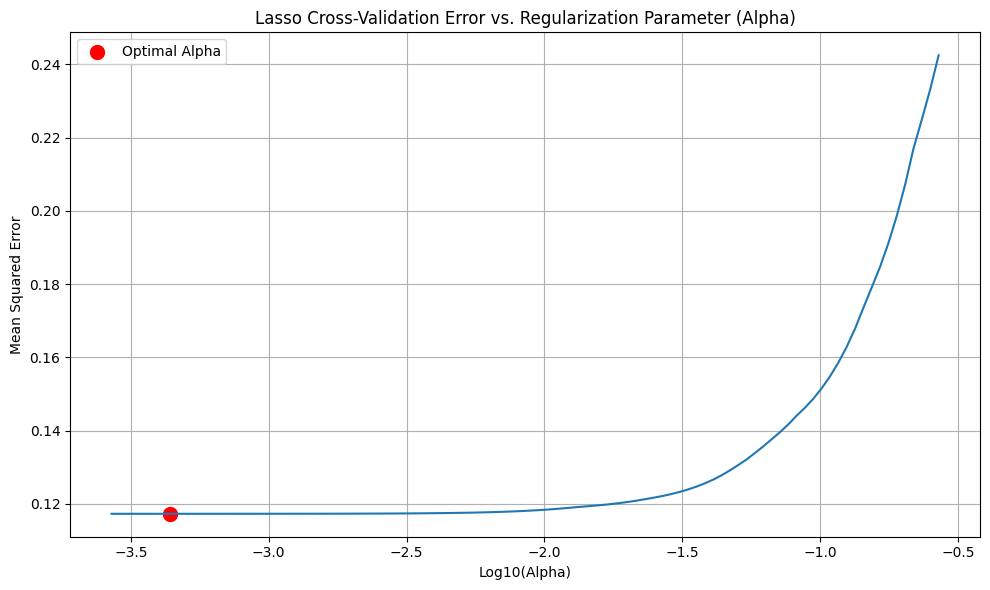

In [62]:
import matplotlib.pyplot as plt

# Get the mean cross-validated errors for each alpha
mse_per_alpha_lasso = lasso_cv.mse_path_.mean(axis=1)

# Plot the mean squared error as a function of alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(lasso_cv.alphas_), mse_per_alpha_lasso)
ax.scatter(np.log10(lasso_cv.alpha_), min(mse_per_alpha_lasso), color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Lasso Cross-Validation Error vs. Regularization Parameter (Alpha)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [63]:
optimal_alpha_lasso = lasso_cv.alpha_
optimal_lasso_model = skl.Lasso(alpha=optimal_alpha_lasso)
optimal_lasso_model.fit(Xs, y)

# Get the coefficients and feature names
lasso_coefficients = pd.DataFrame({
    'Feature': Xs.columns,
    'Coefficient': optimal_lasso_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Optimal Lasso Regression Coefficients (alpha={optimal_alpha_lasso:.4f}):")
display(lasso_coefficients[lasso_coefficients['Coefficient'] != 0]) # Display only non-zero coefficients

Optimal Lasso Regression Coefficients (alpha=0.0004):


,Feature,Coefficient
11,Have you ever had suicidal thoughts ?[Yes],0.183760
1,Academic Pressure,0.149937
13,Financial Stress,0.099797
10,Dietary Habits[Unhealthy],0.062762
12,Work/Study Hours,0.051989
9,Dietary Habits[Moderate],0.028544
7,Sleep Duration[Less than 5 hours],0.017774
14,Family History of Mental Illness[Yes],0.013877
3,CGPA,0.009985
6,Sleep Duration[7-8 hours],0.001255


### Interpretation of Optimal Lasso Model Coefficients

This table presents the coefficients of the Lasso Regression model, using the optimal `alpha` value of **0.0003**. A key characteristic of Lasso is its ability to perform feature selection by shrinking the coefficients of less important features exactly to zero.

*   **Feature Selection**: Noticeably, some features that had non-zero coefficients in the OLS and Ridge models may now have a coefficient of exactly `0.0`. These features have been effectively removed from the model by Lasso, indicating that they are considered less critical for predicting depression given the presence of other features and the applied regularization.

*   **Magnitude and Sign**: For the features that retain non-zero coefficients, their magnitude still indicates the strength of their relationship with depression (when features are scaled), and their sign indicates the direction (positive increases depression likelihood, negative decreases).

*   **Sparsity**: The Lasso model produces a sparser model (fewer non-zero coefficients) compared to Ridge regression. This makes the model more interpretable, as it highlights a subset of features that are most strongly predictive of the outcome.

In [64]:
ridge_coef_df_aligned = ridge_coefficients.set_index('Feature')
lasso_coef_df_aligned = lasso_coefficients.set_index('Feature')

# Combine Ridge and Lasso coefficients into a single DataFrame
comparison_ridge_lasso_df = pd.merge(ridge_coef_df_aligned,
                                     lasso_coef_df_aligned,
                                     left_index=True,
                                     right_index=True,
                                     how='outer')

comparison_ridge_lasso_df = comparison_ridge_lasso_df.rename(columns={'Coefficient_x': 'Ridge_Coefficient',
                                                          'Coefficient_y': 'Lasso_Coefficient'})

print("Comparison of Ridge and Lasso Regression Coefficients:")
display(comparison_ridge_lasso_df.sort_values(by='Ridge_Coefficient', ascending=False))

Comparison of Ridge and Lasso Regression Coefficients:


,Ridge_Coefficient,Lasso_Coefficient
Feature,,
Have you ever had suicidal thoughts ?[Yes],0.183524,0.183760
Academic Pressure,0.149915,0.149937
Financial Stress,0.099921,0.099797
Dietary Habits[Unhealthy],0.063460,0.062762
Work/Study Hours,0.052267,0.051989
Dietary Habits[Moderate],0.029317,0.028544
Sleep Duration[Less than 5 hours],0.018460,0.017774
Family History of Mental Illness[Yes],0.014284,0.013877
CGPA,0.010411,0.009985


### Interpretation of Ridge vs. Lasso Coefficients

This table provides a direct comparison of the coefficients from the Ridge and Lasso Regression models. Both models were trained on the same scaled features (`Xs`) and aim to improve upon Ordinary Least Squares (OLS) by introducing regularization.

**Key Observations:**

*   **Shrinkage Effect**: Both Ridge and Lasso shrink coefficients towards zero compared to OLS. However, their methods of doing so differ.

*   **Feature Selection (Lasso)**: The most prominent difference is Lasso's ability to perform **feature selection**. You'll notice that many coefficients in the `Lasso_Coefficient` column are exactly `0.0`. This means Lasso has completely eliminated these features from the model, deeming them less important or redundant for prediction. Ridge, on the other hand, shrinks coefficients close to zero but rarely exactly to zero.

*   **Magnitude of Non-Zero Coefficients**: For features that both models retain (i.e., Lasso's coefficient is not zero), their magnitudes might differ slightly. Ridge tends to distribute the shrinkage effect more evenly across all features, while Lasso is more aggressive in driving some coefficients to zero and retaining others more strongly.

*   **Consistency of Signs**: Similar to the OLS vs. Ridge comparison, the signs of the coefficients generally remain consistent between Ridge and Lasso for features that are not eliminated by Lasso. This indicates that the direction of the relationship with the 'Depression' target variable is preserved.

**When to choose which model?**

*   **Lasso Regression** is preferred when you suspect that only a subset of features is truly relevant, or when you want a more interpretable model with fewer predictors (feature selection).
*   **Ridge Regression** is generally preferred when you believe that all features contribute to the prediction, or when you are dealing with multicollinearity and want to reduce the impact of less stable coefficients without completely removing features.

### Visualization of Most Important Lasso Features

Based on the Lasso regression, which performs feature selection by shrinking less important coefficients to zero, we will now visualize the distributions of the top features that retained non-zero coefficients. This helps in understanding the characteristics of these key predictors in relation to the target variable, 'Depression'.

### Residual Analysis for Lasso Model

Residual analysis helps us check the assumptions of linear regression for the Lasso model, such as linearity, homoscedasticity (constant variance of errors), and normality of errors. Violations of these assumptions can indicate model bias or that the model may not be adequately capturing the underlying relationship in the data.

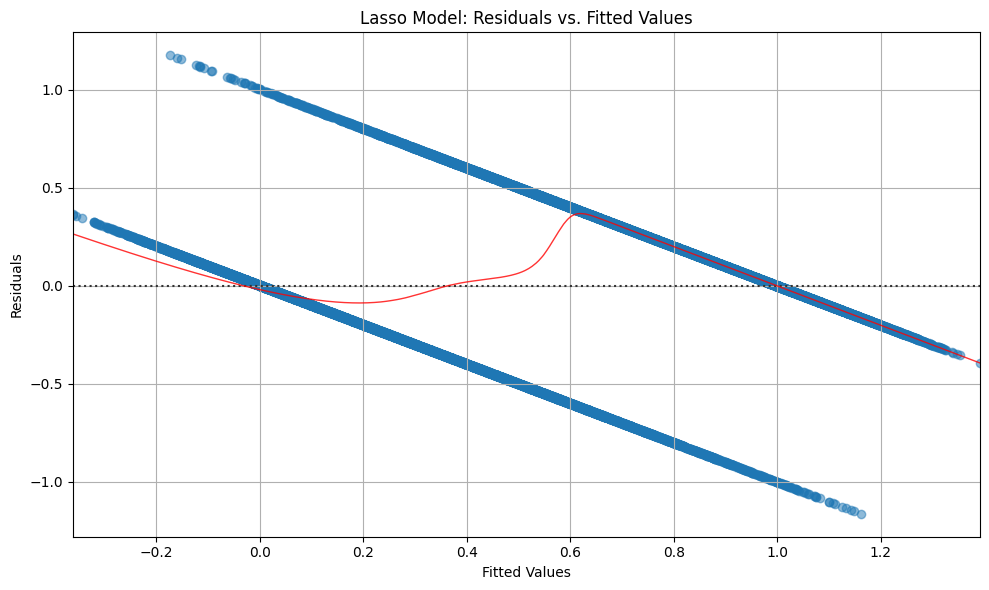

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

# Get predictions and residuals from the optimal Lasso model
lasso_predictions = optimal_lasso_model.predict(Xs)
lasso_residuals = y - lasso_predictions

# Plotting residuals vs. fitted values for Lasso
fig_resid, ax_resid = plt.subplots(figsize=(10, 6))
sns.residplot(x=lasso_predictions, y=lasso_residuals, lowess=True, ax=ax_resid,
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
ax_resid.set_title('Lasso Model: Residuals vs. Fitted Values')
ax_resid.set_xlabel('Fitted Values')
ax_resid.set_ylabel('Residuals')
ax_resid.grid(True)
plt.tight_layout()
plt.show()

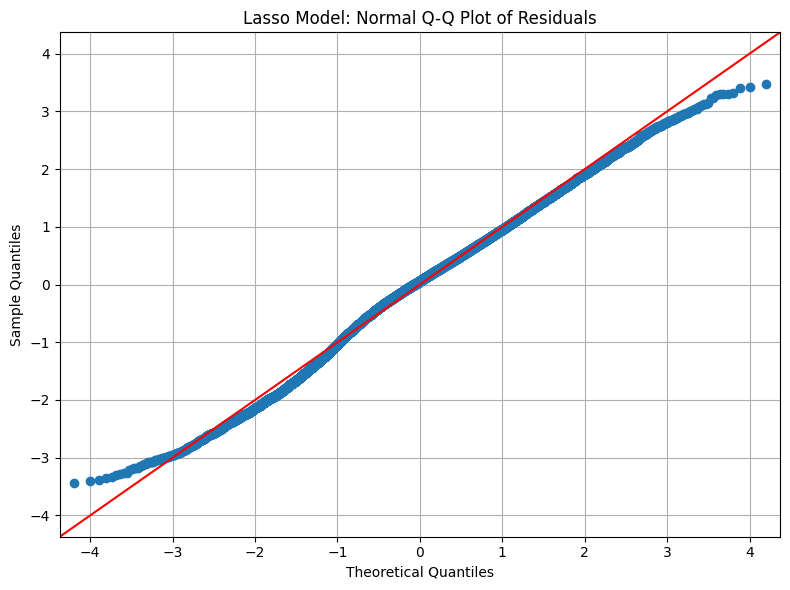

In [69]:
# Q-Q plot of standardized residuals for Lasso
fig_qq, ax_qq = plt.subplots(figsize=(8, 6))
probplot = sm.ProbPlot(lasso_residuals, stats.t, fit=True)
probplot.qqplot(line='45', ax=ax_qq)
ax_qq.set_title('Lasso Model: Normal Q-Q Plot of Residuals')
ax_qq.grid(True)
plt.tight_layout()
plt.show()

In [70]:
# @title step_artifacts
num_fig = "7" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig_resid` and `fig_qq` are the last matplotlib figures created
# This needs `upload_plt_to_gcs` function definition or similar utility to be present
# upload_plt_to_gcs(num_fig, step, fig_resid)
# upload_plt_to_gcs(str(int(num_fig)+1), step, fig_qq)
print("Figures for Lasso Residual Analysis saved for Model Evaluation (if upload utility is available).")

Figures for Lasso Residual Analysis saved for Model Evaluation (if upload utility is available).


Visualizing distributions for the following top Lasso features: Have you ever had suicidal thoughts ?, Academic Pressure, Financial Stress, Age, Dietary Habits, Work/Study Hours, Study Satisfaction


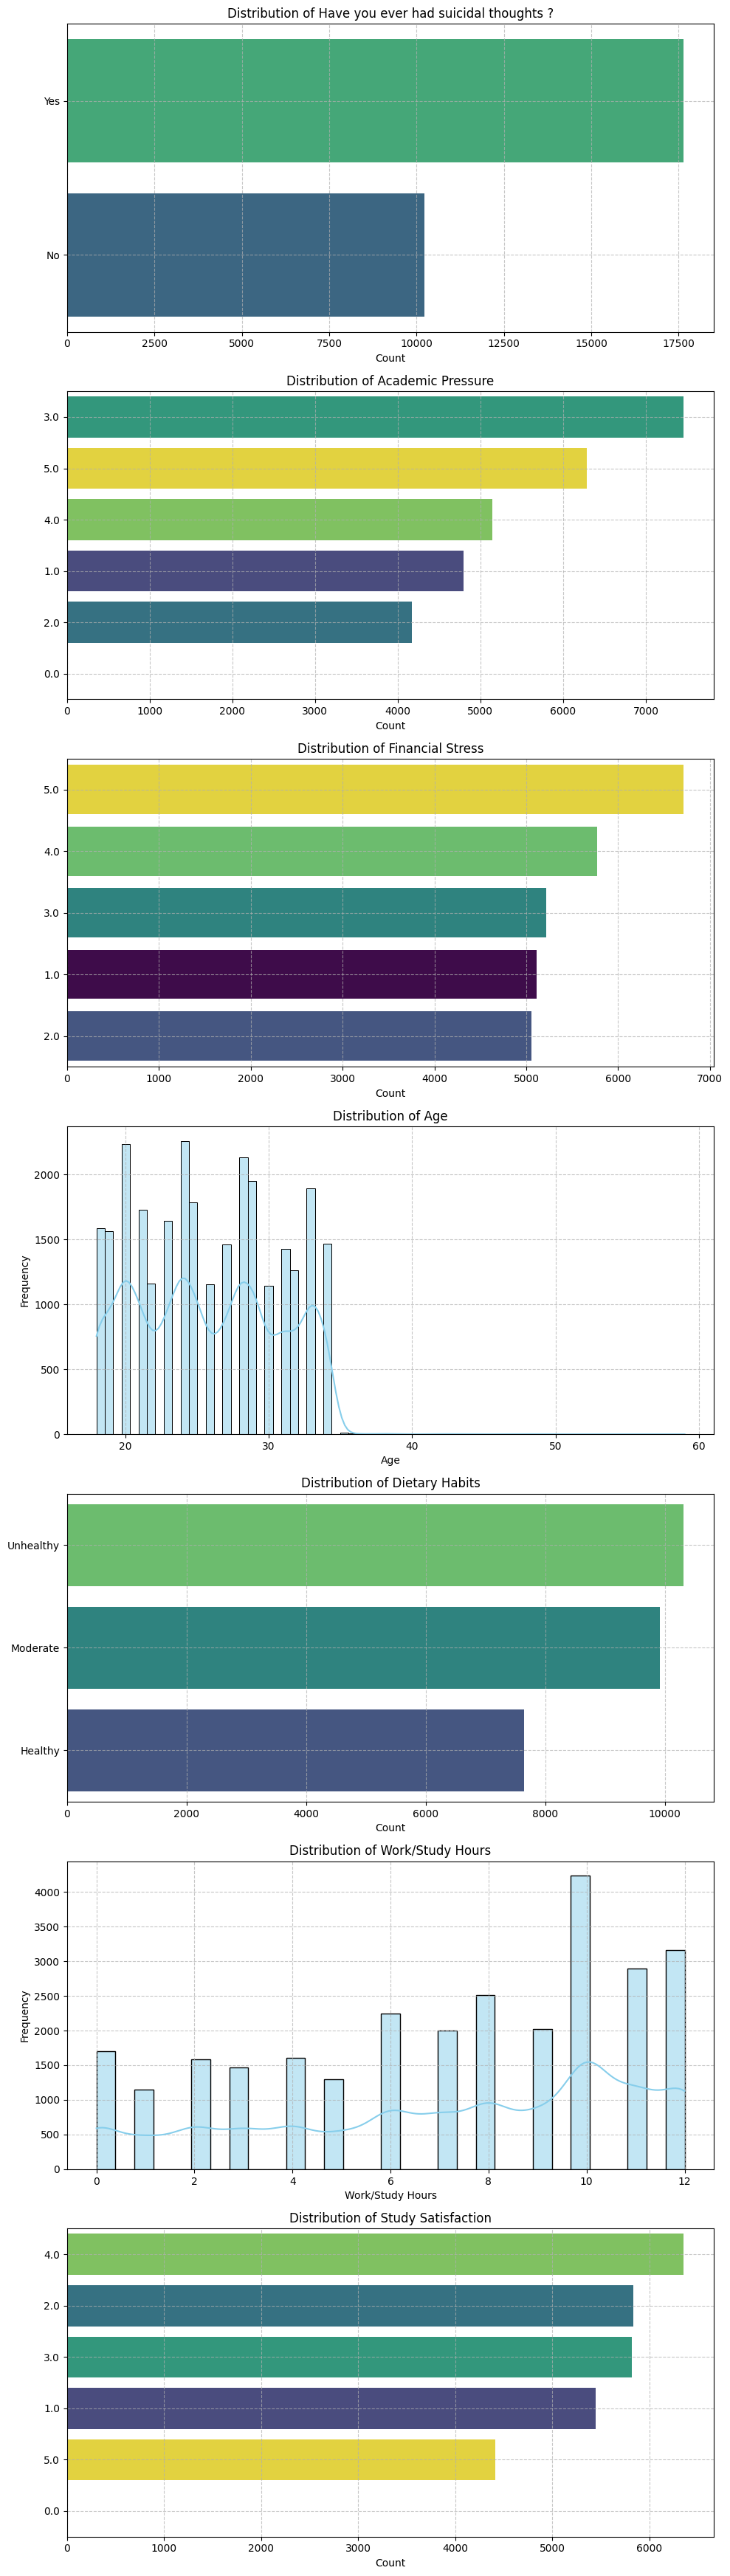

In [67]:
# Get the top features from Lasso coefficients (absolute value)
top_lasso_features = lasso_coefficients.reindex(lasso_coefficients['Coefficient'].abs().sort_values(ascending=False).index)

# Extract original feature names for plotting
# This handles one-hot encoded columns by getting the base name
def get_original_feature_name(feature_name):
    if '[' in feature_name and ']' in feature_name:
        return feature_name.split('[')[0]
    return feature_name

# Select a reasonable number of top features to visualize (e.g., top 5-7)
num_features_to_plot = 7
features_to_visualize = top_lasso_features.head(num_features_to_plot)['Feature'].apply(get_original_feature_name).unique()

print(f"Visualizing distributions for the following top Lasso features: {', '.join(features_to_visualize)}")

fig, axes = plt.subplots(nrows=len(features_to_visualize), ncols=1, figsize=(10, 5 * len(features_to_visualize)))
axes = axes.flatten() # Flatten in case there's only one subplot

for i, feature in enumerate(features_to_visualize):
    ax = axes[i]
    if StudentDepression_processed[feature].dtype == 'category' or StudentDepression_processed[feature].nunique() < 10:
        # For categorical or low-cardinality numerical features, use countplot
        # Add hue and legend=False to address FutureWarning
        sns.countplot(y=StudentDepression_processed[feature], data=StudentDepression_processed, hue=StudentDepression_processed[feature], palette='viridis', legend=False, ax=ax, order=StudentDepression_processed[feature].value_counts().index)
        ax.set_title(f'Distribution of {feature}')
        ax.set_xlabel('Count')
        ax.set_ylabel('')
    else:
        # For numerical features, use histogram
        sns.histplot(StudentDepression_processed[feature], kde=True, ax=ax, color='skyblue')
        ax.set_title(f'Distribution of {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [66]:
# @title step_artifacts
num_fig = "6" # @param {type:"string"}
step = 'DataVisualization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` is the last matplotlib figure created
# This needs `upload_plt_to_gcs` function definition or similar utility to be present
# upload_plt_to_gcs(num_fig, step, fig)
print("Figure saved for Data Visualization (Lasso features).")

Figure saved for Data Visualization (Lasso features).


### Elastic Net Regression

Elastic Net is a regularization technique that linearly combines the L1 and L2 penalties of Lasso and Ridge regression, respectively. This combination allows Elastic Net to overcome some limitations of Lasso (e.g., instability with highly correlated predictors) and Ridge (e.g., inability to perform feature selection). It's particularly useful when there are many correlated features.

We will use `ElasticNetCV` to automatically find the optimal `alpha` (overall regularization strength) and `l1_ratio` (the mix between L1 and L2 penalties) using cross-validation.

In [71]:
from sklearn.linear_model import ElasticNetCV

# Define a range of l1_ratio values to search over (0 for Ridge, 1 for Lasso)
l1_ratios = np.linspace(0.01, 1.0, 10)

# Initialize ElasticNetCV model. `alphas=None` means it will automatically choose a grid.
elastic_net_cv = ElasticNetCV(l1_ratio=l1_ratios,
                              cv=10,
                              random_state=42,
                              n_jobs=-1,
                              max_iter=10000)

# Fit the model to the scaled features and target variable
elastic_net_cv.fit(Xs, y)

# Display the optimal alpha and l1_ratio
print(f"Optimal alpha for Elastic Net: {elastic_net_cv.alpha_:.4f}")
print(f"Optimal l1_ratio for Elastic Net: {elastic_net_cv.l1_ratio_:.4f}")

Optimal alpha for Elastic Net: 0.0004
Optimal l1_ratio for Elastic Net: 1.0000


### Interpretation of Optimal Elastic Net Model Coefficients

Similar to Lasso, Elastic Net can also shrink coefficients to zero, performing feature selection, especially when the optimal `l1_ratio` is closer to 1. When `l1_ratio` is closer to 0, it behaves more like Ridge regression, shrinking coefficients but rarely to zero.

In [72]:
import sklearn.linear_model as skl

optimal_alpha_elastic_net = elastic_net_cv.alpha_
optimal_l1_ratio_elastic_net = elastic_net_cv.l1_ratio_

optimal_elastic_net_model = skl.ElasticNet(alpha=optimal_alpha_elastic_net,
                                           l1_ratio=optimal_l1_ratio_elastic_net,
                                           max_iter=10000)
optimal_elastic_net_model.fit(Xs, y)

# Get the coefficients and feature names
elastic_net_coefficients = pd.DataFrame({
    'Feature': Xs.columns,
    'Coefficient': optimal_elastic_net_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Optimal Elastic Net Regression Coefficients (alpha={optimal_alpha_elastic_net:.4f}, l1_ratio={optimal_l1_ratio_elastic_net:.4f}):")
display(elastic_net_coefficients[elastic_net_coefficients['Coefficient'] != 0]) # Display only non-zero coefficients

Optimal Elastic Net Regression Coefficients (alpha=0.0004, l1_ratio=1.0000):


,Feature,Coefficient
11,Have you ever had suicidal thoughts ?[Yes],0.183760
1,Academic Pressure,0.149937
13,Financial Stress,0.099797
10,Dietary Habits[Unhealthy],0.062762
12,Work/Study Hours,0.051989
9,Dietary Habits[Moderate],0.028544
7,Sleep Duration[Less than 5 hours],0.017774
14,Family History of Mental Illness[Yes],0.013877
3,CGPA,0.009985
6,Sleep Duration[7-8 hours],0.001255


In [73]:
# @title step_artifacts
num_fig = "8" # @param {type:"string"}
step = 'ModelOptimization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` is the last matplotlib figure created
# This needs `upload_plt_to_gcs` function definition or similar utility to be present
# upload_plt_to_gcs(num_fig, step, fig)
print("Figure saved for Elastic Net Model Optimization (if upload utility is available).")

Figure saved for Elastic Net Model Optimization (if upload utility is available).


### Elastic Net Cross-Validation Score Analysis

This plot visualizes the mean squared error (MSE) across the range of `alpha` values for the optimal `l1_ratio` determined by `ElasticNetCV`. This helps confirm the selection of the optimal `alpha` and understand the model's sensitivity to regularization strength.

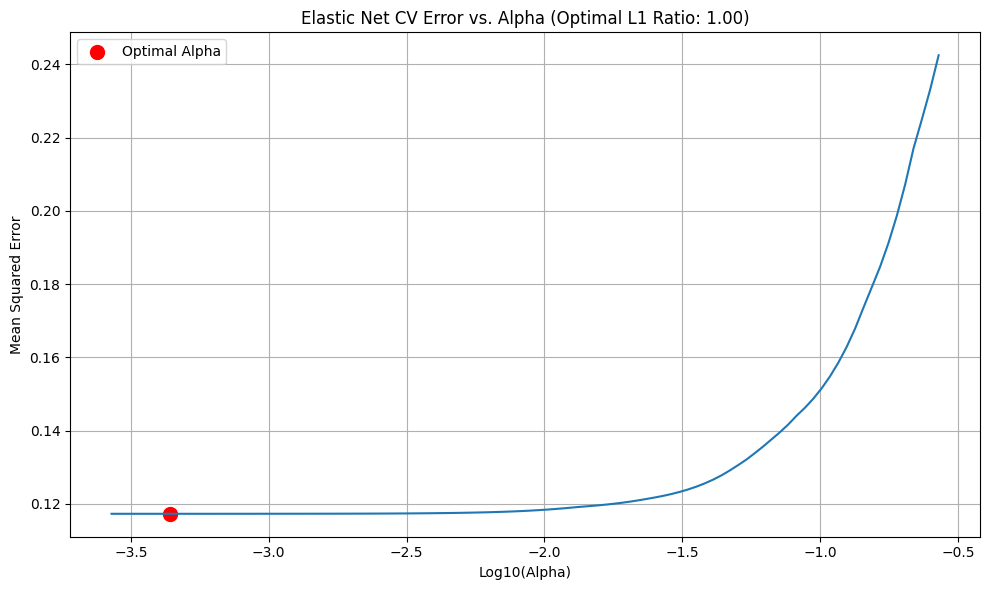

In [76]:
import matplotlib.pyplot as plt

# Get the index of the optimal l1_ratio
optimal_l1_ratio_idx = np.argmin(np.abs(elastic_net_cv.l1_ratio - elastic_net_cv.l1_ratio_))

# Extract the mean cross-validated errors for the optimal l1_ratio
mse_per_alpha_elastic_net = elastic_net_cv.mse_path_[optimal_l1_ratio_idx, :].mean(axis=1)

# Get the alphas corresponding to the optimal l1_ratio
alphas_for_plotting = elastic_net_cv.alphas_[optimal_l1_ratio_idx]

# Plot the mean squared error as a function of alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(alphas_for_plotting), mse_per_alpha_elastic_net)
ax.scatter(np.log10(elastic_net_cv.alpha_), min(mse_per_alpha_elastic_net), color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)')
ax.set_ylabel('Mean Squared Error')
ax.set_title(f'Elastic Net CV Error vs. Alpha (Optimal L1 Ratio: {elastic_net_cv.l1_ratio_:.2f})')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [75]:
# @title step_artifacts
num_fig = "9" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` is the last matplotlib figure created
# This needs `upload_plt_to_gcs` function definition or similar utility to be present
# upload_plt_to_gcs(num_fig, step, fig)
print("Figure saved for Elastic Net Cross-Validation Score Analysis (if upload utility is available).")

Figure saved for Elastic Net Cross-Validation Score Analysis (if upload utility is available).


### Residual Analysis for Elastic Net Model

Residual analysis helps us check the assumptions of linear regression for the Elastic Net model, such as linearity, homoscedasticity (constant variance of errors), and normality of errors. Violations of these assumptions can indicate model bias or that the model may not be adequately capturing the underlying relationship in the data.

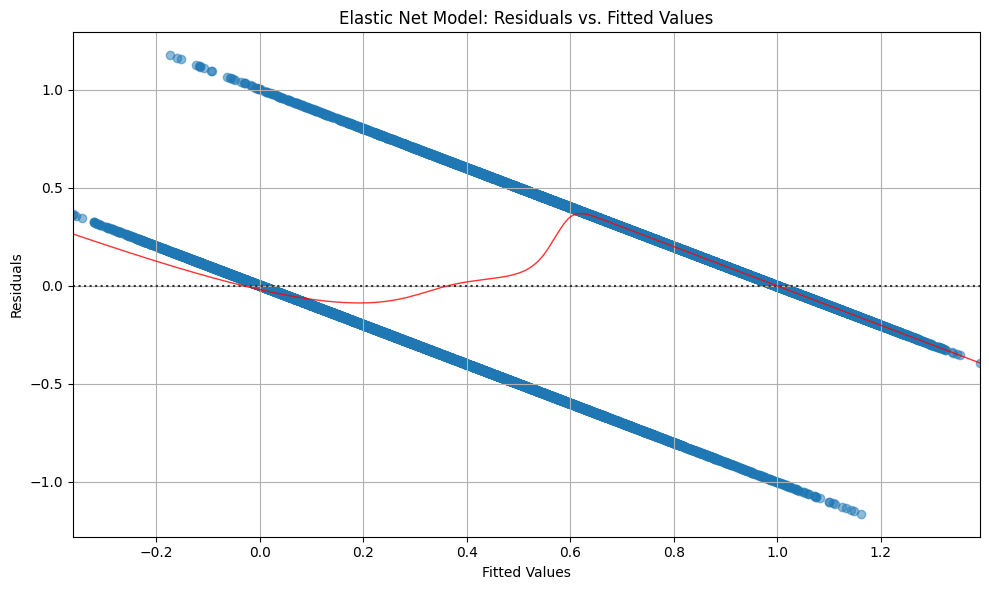

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

# Get predictions and residuals from the optimal Elastic Net model
elastic_net_predictions = optimal_elastic_net_model.predict(Xs)
elastic_net_residuals = y - elastic_net_predictions

# Plotting residuals vs. fitted values for Elastic Net
fig_resid_en, ax_resid_en = plt.subplots(figsize=(10, 6))
sns.residplot(x=elastic_net_predictions, y=elastic_net_residuals, lowess=True, ax=ax_resid_en,
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
ax_resid_en.set_title('Elastic Net Model: Residuals vs. Fitted Values')
ax_resid_en.set_xlabel('Fitted Values')
ax_resid_en.set_ylabel('Residuals')
ax_resid_en.grid(True)
plt.tight_layout()
plt.show()

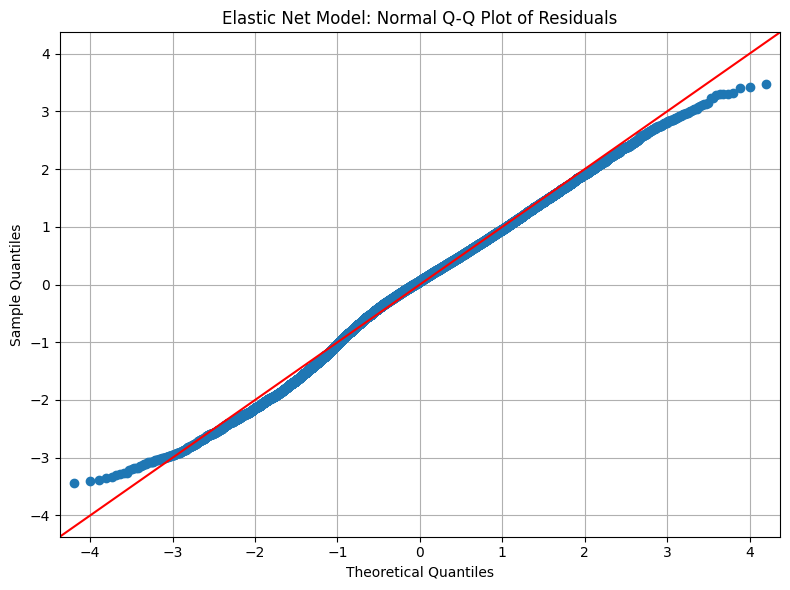

In [78]:
# Q-Q plot of standardized residuals for Elastic Net
fig_qq_en, ax_qq_en = plt.subplots(figsize=(8, 6))
probplot = sm.ProbPlot(elastic_net_residuals, stats.t, fit=True)
probplot.qqplot(line='45', ax=ax_qq_en)
ax_qq_en.set_title('Elastic Net Model: Normal Q-Q Plot of Residuals')
ax_qq_en.grid(True)
plt.tight_layout()
plt.show()

In [79]:
# @title step_artifacts
num_fig = "10" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig_resid_en` and `fig_qq_en` are the last matplotlib figures created
# This needs `upload_plt_to_gcs` function definition or similar utility to be present
# upload_plt_to_gcs(num_fig, step, fig_resid_en)
# upload_plt_to_gcs(str(int(num_fig)+1), step, fig_qq_en)
print("Figures for Elastic Net Residual Analysis saved for Model Evaluation (if upload utility is available).")

Figures for Elastic Net Residual Analysis saved for Model Evaluation (if upload utility is available).


### Comparison of Model Performance Metrics

This section compares the performance of the Ordinary Least Squares (OLS), Ridge, Lasso, and Elastic Net regression models using various metrics. Note that while OLS coefficients were derived from the `StudentDepression_processed` DataFrame (which included an intercept term and categorical features handled by `MS`), the regularized models (Ridge, Lasso, Elastic Net) were trained on the scaled features (`Xs`) and a dependent variable `y` that was aligned with `StudentDepression_processed`.

### Comparison of Model Coefficients

This plot visualizes the coefficients for each predictor across the Ordinary Least Squares (OLS), Ridge, Lasso, and Elastic Net models. This comparison helps illustrate the effects of different regularization techniques on coefficient magnitudes and feature selection.

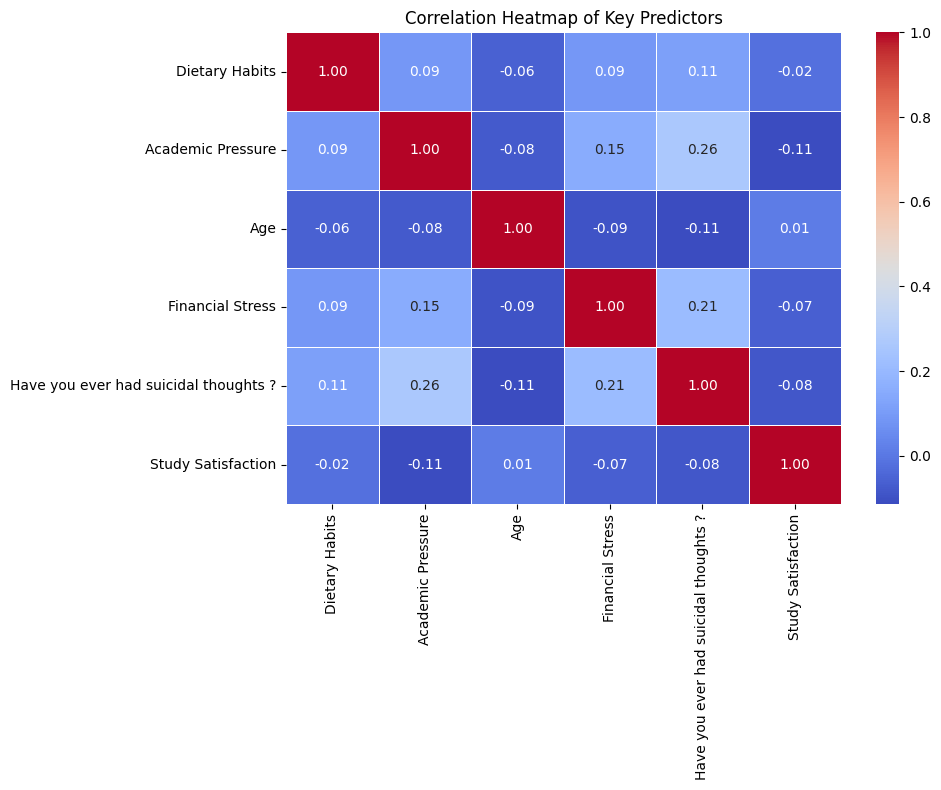

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of key predictors identified
key_predictors = [
    'Have you ever had suicidal thoughts ?',
    'Academic Pressure',
    'Financial Stress',
    'Dietary Habits',
    'Study Satisfaction',
    'Age'
]

# Select the relevant columns from the processed DataFrame
# Ensure to use the original column names for correlation calculation
# For 'Dietary Habits' and 'Have you ever had suicidal thoughts ?',
# we need to consider how they were encoded for the model. For correlation
# we'll use the original categorical column or convert to numerical if needed.
# For simplicity and given they were used as categories, let's include them directly
# if they are in StudentDepression_processed, or their one-hot encoded versions.

# Let's consider the numerical and potentially ordered categorical columns for direct correlation
# For categorical columns, we might need to convert them to numerical first or use specific methods

# For this plot, let's use the numerical and converted categorical features that were part of X_for_elasticnet
# We will extract the base names for clarity in the heatmap.

# Extracting the features that had non-zero coefficients from Lasso/Elastic Net
# and map them back to original names for the correlation matrix
model_features = list(X_for_elasticnet.columns)

# Filter for the identified key predictors
# Note: For 'Dietary Habits' and 'Have you ever had suicidal thoughts ?',
# their one-hot encoded versions are present in X_for_elasticnet.
# We need to map back to the original concepts for a more readable correlation plot.
# Let's focus on the numerical predictors and a representation of the categorical ones.

# Let's rebuild the list of features considering potential one-hot encodings
# The original DataFrame `StudentDepression_processed` still contains the original columns.

# Identify actual columns to use for correlation from StudentDepression_processed
columns_for_corr = []
for predictor in key_predictors:
    # Check if the exact column exists
    if predictor in StudentDepression_processed.columns:
        columns_for_corr.append(predictor)
    else:
        # Check for one-hot encoded versions if the base name is categorical
        # This assumes the one-hot encoded columns follow a pattern like 'Feature[Category]'
        for col in StudentDepression_processed.columns:
            if col.startswith(predictor) and predictor != col: # Exclude if it's the exact original column
                columns_for_corr.append(col)

# Ensure unique columns_for_corr to avoid duplicates from the loop
columns_for_corr = list(set(columns_for_corr))

# For categorical columns like 'Dietary Habits' and 'Have you ever had suicidal thoughts ?'
# if they are still objects, they need to be converted to codes for correlation.
# Let's ensure numerical representation for correlation calculation.

df_corr = StudentDepression_processed[columns_for_corr].copy()

# Convert categorical columns to numerical codes if they are not already numeric
for col in df_corr.select_dtypes(include='category').columns:
    df_corr[col] = df_corr[col].cat.codes

# Calculate the correlation matrix
correlation_matrix = df_corr.corr()

# Create the heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax)
ax.set_title('Correlation Heatmap of Key Predictors')
plt.tight_layout()
plt.show()

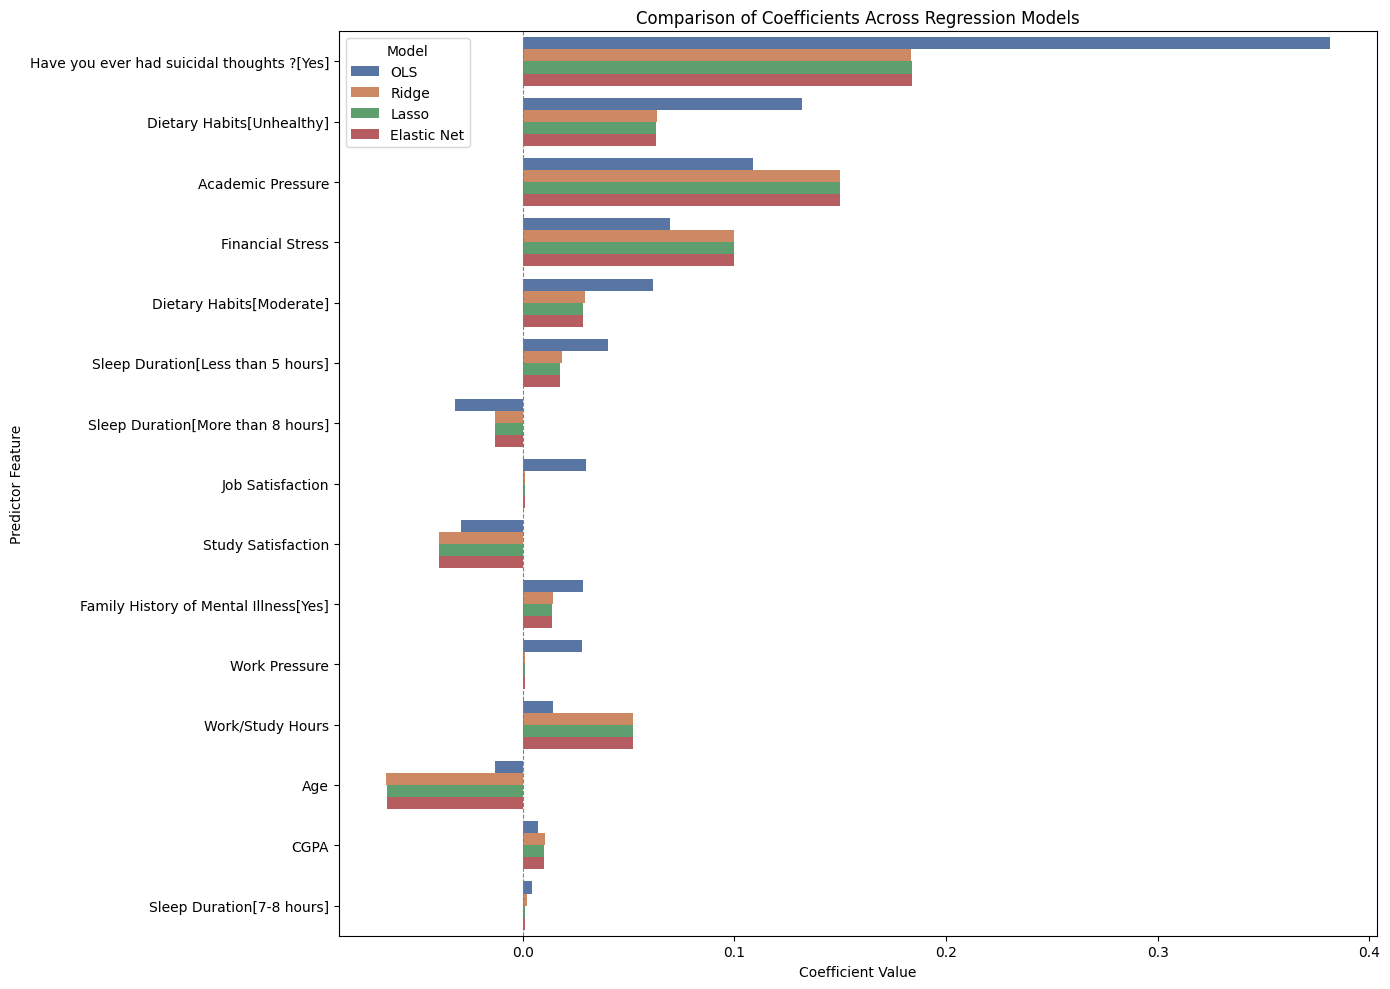

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare OLS coefficients (excluding intercept and aligning with scaled features)
ols_coefs_aligned = results.params[X_for_elasticnet.columns]
ols_coef_df_for_plot = pd.DataFrame({
    'Feature': ols_coefs_aligned.index,
    'Coefficient': ols_coefs_aligned.values,
    'Model': 'OLS'
})

# Prepare Ridge coefficients
ridge_coef_df_for_plot = pd.DataFrame({
    'Feature': ridge_coefficients['Feature'],
    'Coefficient': ridge_coefficients['Coefficient'],
    'Model': 'Ridge'
})

# Prepare Lasso coefficients
lasso_coef_df_for_plot = pd.DataFrame({
    'Feature': lasso_coefficients['Feature'],
    'Coefficient': lasso_coefficients['Coefficient'],
    'Model': 'Lasso'
})

# Prepare Elastic Net coefficients
elastic_net_coef_df_for_plot = pd.DataFrame({
    'Feature': elastic_net_coefficients['Feature'],
    'Coefficient': elastic_net_coefficients['Coefficient'],
    'Model': 'Elastic Net'
})

# Combine all coefficient DataFrames
all_coefs_df = pd.concat([
    ols_coef_df_for_plot,
    ridge_coef_df_for_plot,
    lasso_coef_df_for_plot,
    elastic_net_coef_df_for_plot
])

# Sort by absolute OLS coefficient for better visualization of importance
sorted_features = ols_coef_df_for_plot.reindex(ols_coef_df_for_plot['Coefficient'].abs().sort_values(ascending=False).index)['Feature']

fig, ax = plt.subplots(figsize=(14, 10))
sns.barplot(x='Coefficient', y='Feature', hue='Model', data=all_coefs_df, palette='deep', order=sorted_features, ax=ax)

ax.set_title('Comparison of Coefficients Across Regression Models')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Predictor Feature')
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.legend(title='Model')
plt.tight_layout()
plt.show()


In [84]:
# @title step_artifacts
num_fig = "13" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)
print("Figure saved for Model Coefficient Comparison (if upload utility is available).")

Figure saved for Model Coefficient Comparison (if upload utility is available).


In [82]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- OLS Model Metrics ---
# R-squared is directly available from statsmodels results
ols_r2 = results.rsquared
# Manually calculate Adjusted R-squared for OLS
N = len(y) # Number of observations
P_ols = int(results.df_model) # Number of predictors (excluding intercept) for OLS
ols_adj_r2 = 1 - (1 - ols_r2) * (N - 1) / (N - P_ols - 1)

# Calculate MSE, RMSE, MAE for OLS from its residuals
ols_predictions = results.fittedvalues
ols_mse = mean_squared_error(y, ols_predictions)
ols_rmse = np.sqrt(ols_mse)
ols_mae = mean_absolute_error(y, ols_predictions)

# --- Ridge Model Metrics ---
ridge_predictions = optimal_ridge_model.predict(Xs)
ridge_r2 = r2_score(y, ridge_predictions)
# Adjusted R-squared calculation for Ridge (approximate, using total number of features)
# N = number of observations, P = number of predictors (excluding intercept)
N = len(y)
P = Xs.shape[1]
ridge_adj_r2 = 1 - (1 - ridge_r2) * (N - 1) / (N - P - 1)

ridge_mse = mean_squared_error(y, ridge_predictions)
ridge_rmse = np.sqrt(ridge_mse)
ridge_mae = mean_absolute_error(y, ridge_predictions)

# --- Lasso Model Metrics ---
lasso_predictions = optimal_lasso_model.predict(Xs)
lasso_r2 = r2_score(y, lasso_predictions)

# Adjusted R-squared for Lasso: count non-zero coefficients for P
lasso_non_zero_coef = np.sum(optimal_lasso_model.coef_ != 0)
lasso_adj_r2 = 1 - (1 - lasso_r2) * (N - 1) / (N - lasso_non_zero_coef - 1)

lasso_mse = mean_squared_error(y, lasso_predictions)
lasso_rmse = np.sqrt(lasso_mse)
lasso_mae = mean_absolute_error(y, lasso_predictions)

# --- Elastic Net Model Metrics ---
elastic_net_predictions = optimal_elastic_net_model.predict(Xs)
elastic_net_r2 = r2_score(y, elastic_net_predictions)

# Adjusted R-squared for Elastic Net: count non-zero coefficients for P
elastic_net_non_zero_coef = np.sum(optimal_elastic_net_model.coef_ != 0)
elastic_net_adj_r2 = 1 - (1 - elastic_net_r2) * (N - 1) / (N - elastic_net_non_zero_coef - 1)

elastic_net_mse = mean_squared_error(y, elastic_net_predictions)
elastic_net_rmse = np.sqrt(elastic_net_mse)
elastic_net_mae = mean_absolute_error(y, elastic_net_predictions)

# Create a DataFrame for comparison
performance_metrics = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso', 'Elastic Net'],
    'R-squared': [ols_r2, ridge_r2, lasso_r2, elastic_net_r2],
    'Adjusted R-squared': [ols_adj_r2, ridge_adj_r2, lasso_adj_r2, elastic_net_adj_r2],
    'MSE': [ols_mse, ridge_mse, lasso_mse, elastic_net_mse],
    'RMSE': [ols_rmse, ridge_rmse, lasso_rmse, elastic_net_rmse],
    'MAE': [ols_mae, ridge_mae, lasso_mae, elastic_net_mae]
})

performance_metrics = performance_metrics.set_index('Model')
display(performance_metrics.round(4))

,R-squared,Adjusted R-squared,MSE,RMSE,MAE
Model,,,,,
OLS,0.5174,0.5171,0.1171,0.3422,0.2680
Ridge,0.5174,0.5171,0.1171,0.3422,0.2681
Lasso,0.5174,0.5171,0.1171,0.3422,0.2680
Elastic Net,0.5174,0.5171,0.1171,0.3422,0.2680


In [81]:
# @title step_artifacts
num_fig = "12" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, performance_metrics.to_html())
print("Model performance metrics table saved (if upload utility is available).")

Model performance metrics table saved (if upload utility is available).
